Loading of the dataset

In [ ]:
import pandas as pd
from settings import HOUSING
df = pd.read_csv(HOUSING)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [3]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Identifying which fields correlates more towards price

In [4]:
corr = df.corr(numeric_only=True)
price_corr = corr['price'].sort_values(ascending = False)
price_corr

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64

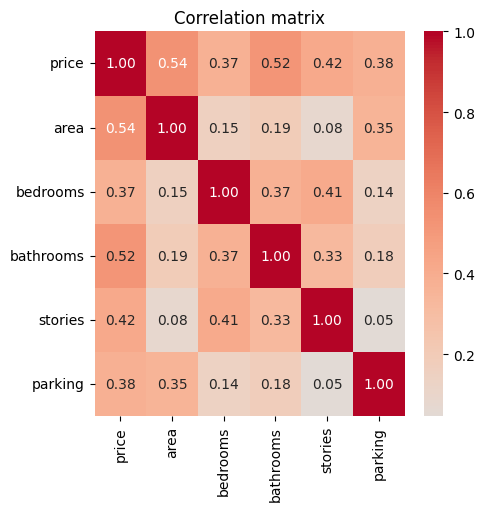

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.show()

In [6]:
df["furnishingstatus"].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

Encoding binary columns

In [7]:
binary_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
for col in binary_cols:
    df[col] = df[col].astype(str).str.strip().str.lower().map({'yes': 1, 'no': 0})

Encoding multi categories with one hot encoding

In [8]:
df = pd.get_dummies(df , columns=["furnishingstatus"])

In [9]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,True,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,True,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,False,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,True,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,True,False,False


Standard Scaling(based on z score) and train test splitting

In [10]:
from sklearn.model_selection import train_test_split
y = df['price']
X = df.drop(['price'] ,axis = 1)



In [11]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

In [12]:
from sklearn.preprocessing import StandardScaler
num_cols = ['area','bedrooms','bathrooms','stories','parking']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.fit_transform(X_test[num_cols])

In [13]:
X_train_mat = X_train.to_numpy()
y_train_vec = y_train.to_numpy()

In [14]:
X_test_mat = X_test.to_numpy()
y_test_vec = y_test.to_numpy()

In [15]:
X_train_mat.shape

(436, 14)

In [16]:
y_train_vec.shape

(436,)

In [17]:
X_train_mat

array([[0.3841681916104767, 0.055270920014809204, 1.539173229085006, ...,
        True, False, False],
       [0.9291806995772802, 0.055270920014809204, 1.539173229085006, ...,
        False, True, False],
       [-0.6077545728891056, -1.2835135870105665, -0.5579502955433145,
        ..., True, False, False],
       ...,
       [-0.2970974433480276, 0.055270920014809204, 1.539173229085006,
        ..., True, False, False],
       [-0.5060189047353023, -1.2835135870105665, -0.5579502955433145,
        ..., False, False, True],
       [0.1570796466243086, 0.055270920014809204, 1.539173229085006, ...,
        False, True, False]], shape=(436, 14), dtype=object)

In [18]:
import numpy as np

In [19]:
X_train_mat = X_train_mat.astype(np.float64)
y_train_vec = y_train_vec.astype(np.float64)

In [20]:
X_test_mat = X_train_mat.astype(np.float64)
y_test_vec = y_train_vec.astype(np.float64)

Linear regression start

In [29]:
import numpy as np
#initialise parameter
m , n = X_train_mat.shape
w = np.zeros((n , 1))
lr = 0.01
epochs = 100
b = 0

In [30]:
w.shape

(14, 1)

In [31]:
#training
y_train_vec = y_train_vec.reshape(-1, 1)
c = 0
losses = []
for _ in range(epochs):
    y_hat = X_train_mat @ w + b
    #print(y_hat.shape)
    loss = np.mean((y_hat - y_train_vec) ** 2)
    losses.append(loss)
    dw = (2/m) * X_train_mat.T @ (y_hat - y_train_vec)
    #print(dw.shape)
    db = (2/m) * np.sum(y_hat - y_train_vec)
    #print(db.shape)
    w -= lr * dw
    b -= lr * db
    c += 1
print(c)
print(w, b)




100
[[ 393982.78344428]
 [ 152435.11290318]
 [ 465054.33109585]
 [ 320288.92394088]
 [1550062.07470734]
 [ 351944.64183124]
 [ 641048.85514568]
 [ 155593.53604992]
 [ 745854.61359039]
 [ 197436.53247727]
 [ 502262.02378149]
 [ 635619.01119321]
 [ 797166.80175826]
 [ 533017.44011853]] 1965803.2530699992


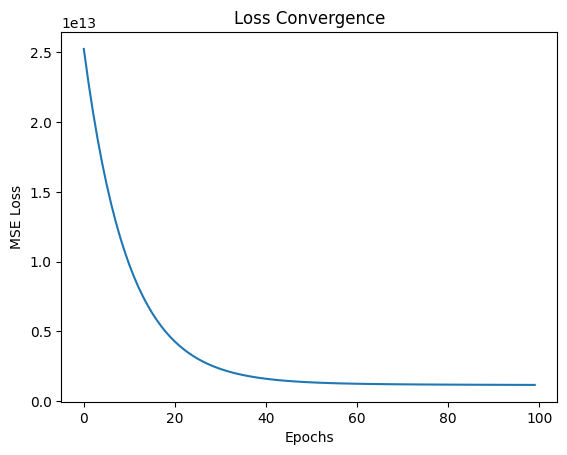

In [32]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Loss Convergence")
plt.show()


Testing the model

In [33]:
y_test_vec = y_test_vec.reshape(-1, 1)
y_test_pred = X_test_mat @ w + b


In [34]:
test_mse = np.mean((y_test_pred - y_test_vec) ** 2)
print("Test MSE:", test_mse)


Test MSE: 1173342349675.9946


In [35]:
test_rmse = np.sqrt(test_mse)
print("Test RMSE:", test_rmse)


Test RMSE: 1083209.2824916127


In [36]:
y_true = y_test_vec.flatten()
y_pred = y_test_pred.flatten()
error = y_pred - y_true
abs_error = np.abs(error)
import pandas as pd

results_df = pd.DataFrame({
    "True Price": y_true,
    "Predicted Price": y_pred,
    "Error (Pred - True)": error,
    "Absolute Error": abs_error
})

results_df.head(10)


,True Price,Predicted Price,Error (Pred - True),Absolute Error
0,7525000.0,6.674361e+06,-8.506393e+05,8.506393e+05
1,6300000.0,7.033028e+06,7.330284e+05,7.330284e+05
2,3920000.0,4.855399e+06,9.353992e+05,9.353992e+05
3,3430000.0,4.408767e+06,9.787669e+05,9.787669e+05
4,3010000.0,3.469445e+06,4.594453e+05,4.594453e+05
5,4620000.0,4.600105e+06,-1.989470e+04,1.989470e+04
6,1750000.0,3.487339e+06,1.737339e+06,1.737339e+06
7,3010000.0,1.782969e+06,-1.227031e+06,1.227031e+06
8,2520000.0,1.443703e+06,-1.076297e+06,1.076297e+06
9,3710000.0,3.766098e+06,5.609816e+04,5.609816e+04


In [37]:
pd.options.display.float_format = '{:,.0f}'.format


In [38]:
results_df.head(10)


,True Price,Predicted Price,Error (Pred - True),Absolute Error
0,"7,525,000","6,674,361","-850,639","850,639"
1,"6,300,000","7,033,028","733,028","733,028"
2,"3,920,000","4,855,399","935,399","935,399"
3,"3,430,000","4,408,767","978,767","978,767"
4,"3,010,000","3,469,445","459,445","459,445"
5,"4,620,000","4,600,105","-19,895","19,895"
6,"1,750,000","3,487,339","1,737,339","1,737,339"
7,"3,010,000","1,782,969","-1,227,031","1,227,031"
8,"2,520,000","1,443,703","-1,076,297","1,076,297"
9,"3,710,000","3,766,098","56,098","56,098"
